In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [ ]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c state-farm-distracted-driver-detection

 99% 3.97G/4.00G [01:01<00:00, 37.6MB/s]
100% 4.00G/4.00G [01:01<00:00, 69.9MB/s]


In [ ]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [ ]:
import os

print(os.listdir("/content/data/imgs/train"))

['c5', 'c7', 'c8', 'c4', 'c0', 'c1', 'c2', 'c6', 'c3', 'c9']


In [ ]:
import shutil
import random
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.layers import Dense
import matplotlib.pyplot as plt

In [ ]:
# paths
SOURCE_TRAIN_DIR = "/content/data/imgs/train"
PROCESSED_DIR = "/content/data/processed"

CLASS_NAMES = ["c0","c1","c2","c3","c4","c5","c6","c7","c8","c9"]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

RANDOM_SEED = 42

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [ ]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [ ]:
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        create_dir(os.path.join(PROCESSED_DIR, split, cls))

In [ ]:
# data split
random.seed(RANDOM_SEED)

for cls in CLASS_NAMES:
    cls_path = os.path.join(SOURCE_TRAIN_DIR, cls)
    images = [img for img in os.listdir(cls_path) if img.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "test", cls, img)
        )

    print(f"{cls}: {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

c0: 1493 train | 498 val | 498 test
c1: 1360 train | 453 val | 454 test
c2: 1390 train | 463 val | 464 test
c3: 1407 train | 469 val | 470 test
c4: 1395 train | 465 val | 466 test
c5: 1387 train | 462 val | 463 test
c6: 1395 train | 465 val | 465 test
c7: 1201 train | 400 val | 401 test
c8: 1146 train | 382 val | 383 test
c9: 1277 train | 426 val | 426 test


In [ ]:
def count_images(split):
    total = 0
    for cls in CLASS_NAMES:
        total += len(os.listdir(os.path.join(PROCESSED_DIR, split, cls)))
    return total

print("Train images:", count_images("train"))
print("Val images:", count_images("val"))
print("Test images:", count_images("test"))

Train images: 13451
Val images: 4483
Test images: 4490


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Found 13451 files belonging to 10 classes.
Found 4483 files belonging to 10 classes.
Found 4490 files belonging to 10 classes.


In [ ]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (16, 224, 224, 3)
Labels shape: (16, 10)


In [ ]:
def original_model(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 2
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Bloack 3
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 4
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # conv 9 & 10
  x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(num_classes, (3, 3), padding="same")(x)

  # Global pooling layer
  x = layers.GlobalAveragePooling2D()(x)

  # Softmax
  outputs = layers.Softmax()(x)

  model = models.Model(inputs, outputs, name="Original_CNN")
  return model

In [ ]:
model1 = original_model()
model1.summary()

Model: "Original_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 14, 14, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 10)     │        23,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 10)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,474 (2.47 MB)

 Trainable params: 648,474 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200


KeyboardInterrupt: 

In [ ]:
model1.save("/content/data/models/original_cnn.keras")

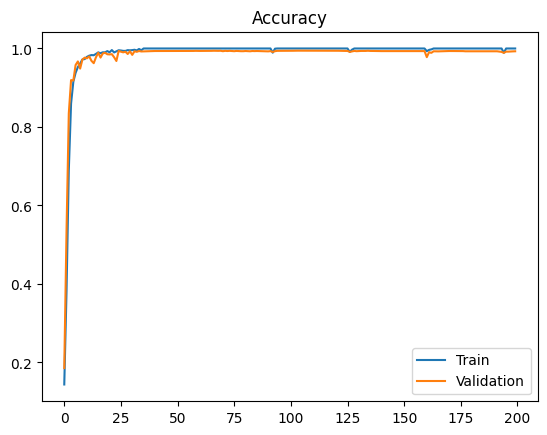

In [ ]:
# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

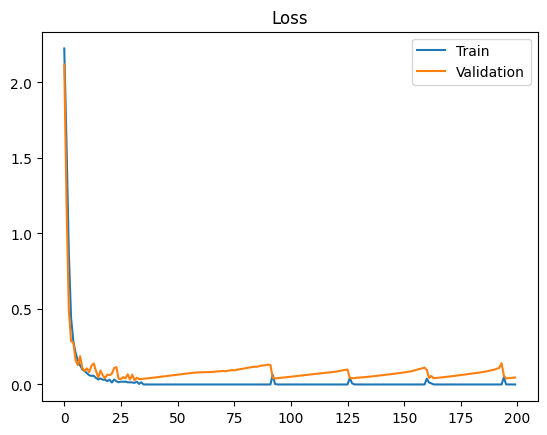

In [ ]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model1.evaluate(test_ds)
print("Test Accuracy:", test_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9929 - loss: 0.0765
Test Accuracy: 0.9908685684204102


In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
Time per image (seconds): 0.08327989280223846


In [ ]:
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

Time per image (milliseconds): 83.27989280223846


In [ ]:
def original_model_mod1(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 2
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Bloack 3
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 4
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # conv 9
  x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)

  # Global pooling layer
  x = layers.GlobalAveragePooling2D()(x)

  outputs = layers.Dense(10,activation="softmax")(x)

  model = models.Model(inputs, outputs, name="Original_CNN_mod1")
  return model

In [ ]:
model1a = original_model_mod1()
model1a.summary()

Model: "Original_CNN_mod1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 56, 56, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 28, 28, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 14, 14, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,994 (2.40 MB)

 Trainable params: 627,994 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1a.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mod1 = model1a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 73s 76ms/step - accuracy: 0.1096 - loss: 2.3121 - val_accuracy: 0.2931 - val_loss: 1.8583
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.3615 - loss: 1.6681 - val_accuracy: 0.6732 - val_loss: 0.9588
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.6830 - loss: 0.9319 - val_accuracy: 0.8621 - val_loss: 0.4549
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.8457 - loss: 0.4852 - val_accuracy: 0.9141 - val_loss: 0.2854
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9142 - loss: 0.2895 - val_accuracy: 0.8563 - val_loss: 0.4171
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9364 - loss: 0.2172 - val_accuracy: 0.9572 - val_loss: 0.1377
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9552 - loss: 0.1533 - val_accuracy: 0.9688 - val_loss: 0.1133
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9666 - loss: 0

In [ ]:
model1a.save("/content/data/models/original_cnn_mod1.keras")

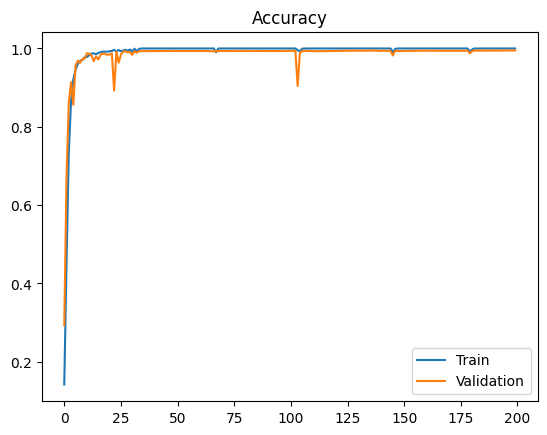

In [ ]:
# Accuracy curve
plt.plot(history_mod1.history['accuracy'])
plt.plot(history_mod1.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

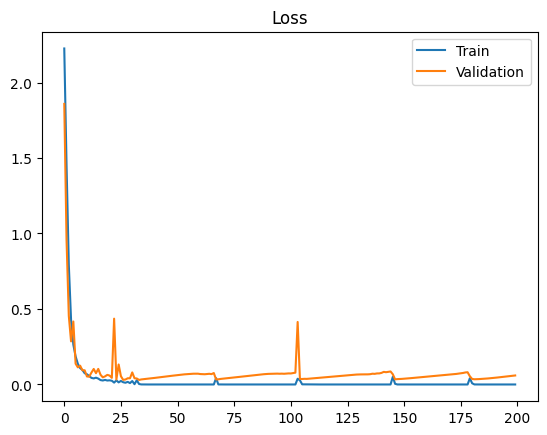

In [ ]:
# Loss curve
plt.plot(history_mod1.history['loss'])
plt.plot(history_mod1.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model1a.evaluate(test_ds)
print("Test Accuracy:", test_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9945 - loss: 0.0713
Test Accuracy: 0.993318498134613


In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1a.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 980ms/step
Time per image (seconds): 0.06448820233345032


In [ ]:
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

Time per image (milliseconds): 64.48820233345032


In [ ]:
def original_model_mod2(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 2
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Bloack 3
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 4
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Global pooling layer
  x = layers.GlobalAveragePooling2D()(x)

  outputs = layers.Dense(10,activation="softmax")(x)

  model = models.Model(inputs, outputs, name="Original_CNN_mod2")
  return model

In [ ]:
model1b = original_model_mod2()
model1b.summary()

Model: "Original_CNN_mod2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 14, 14, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,546 (1.26 MB)

 Trainable params: 331,546 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1b.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mod2 = model1b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 87s 83ms/step - accuracy: 0.1051 - loss: 2.3111 - val_accuracy: 0.1564 - val_loss: 2.2600
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.1963 - loss: 2.1187 - val_accuracy: 0.3221 - val_loss: 1.6130
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.3673 - loss: 1.6059 - val_accuracy: 0.4223 - val_loss: 1.4477
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.5721 - loss: 1.1756 - val_accuracy: 0.6819 - val_loss: 0.8808
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.7107 - loss: 0.8377 - val_accuracy: 0.7731 - val_loss: 0.6834
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.7966 - loss: 0.5991 - val_accuracy: 0.8276 - val_loss: 0.5349
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.8637 - loss: 0.4448 - val_accuracy: 0.8546 - val_loss: 0.4954
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.8941 - loss: 0

In [ ]:
model1b.save("/content/data/models/original_cnn_mod2.keras")

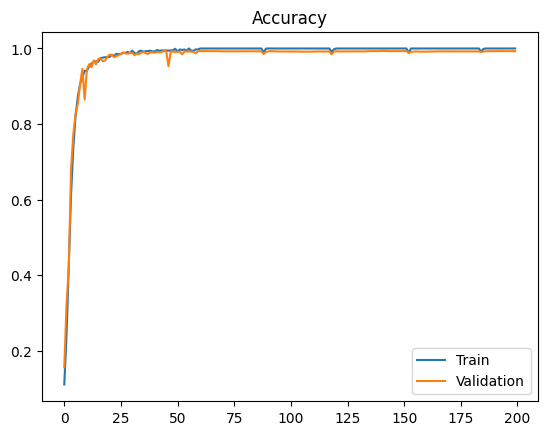

In [ ]:
# Accuracy curve
plt.plot(history_mod2.history['accuracy'])
plt.plot(history_mod2.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

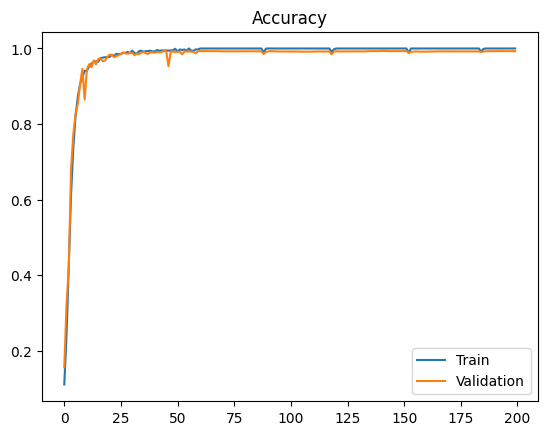

In [ ]:
# Loss curve
plt.plot(history_mod2.history['loss'])
plt.plot(history_mod2.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
val_loss, val_acc = model1b.evaluate(val_ds)
print("Validation Accuracy:", val_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.9952 - loss: 0.0491
Test Accuracy: 0.9930957555770874


In [ ]:
import time
import numpy as np

sample_batch = next(iter(val_ds))[0]

start = time.time()
pred = model1b.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
Time per image (seconds): 0.04065848886966705


In [ ]:
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

Time per image (milliseconds): 40.65848886966705


In [ ]:
def original_model_mod3(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 2
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 3
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Global pooling layer
  x = layers.GlobalAveragePooling2D()(x)

  outputs = layers.Dense(10,activation="softmax")(x)

  model = models.Model(inputs, outputs, name="Original_CNN_mod3")
  return model

In [ ]:
model1c = original_model_mod3()
model1c.summary()

Model: "Original_CNN_mod3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,466 (427.60 KB)

 Trainable params: 109,466 (427.60 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1c.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mod3 = model1c.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 77s 75ms/step - accuracy: 0.1076 - loss: 2.3527 - val_accuracy: 0.1704 - val_loss: 2.2057
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.1970 - loss: 2.1614 - val_accuracy: 0.2523 - val_loss: 1.9415
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.2801 - loss: 1.8904 - val_accuracy: 0.2806 - val_loss: 1.7895
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.3516 - loss: 1.6900 - val_accuracy: 0.4089 - val_loss: 1.5794
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - accuracy: 0.4397 - loss: 1.4777 - val_accuracy: 0.5093 - val_loss: 1.3609
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.5142 - loss: 1.2923 - val_accuracy: 0.6083 - val_loss: 1.1449
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.5983 - loss: 1.1242 - val_accuracy: 0.6449 - val_loss: 1.0616
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 83s 63ms/step - accuracy: 0.6482 - loss: 0

In [ ]:
model1c.save("/content/data/models/original_cnn_mod3.keras")

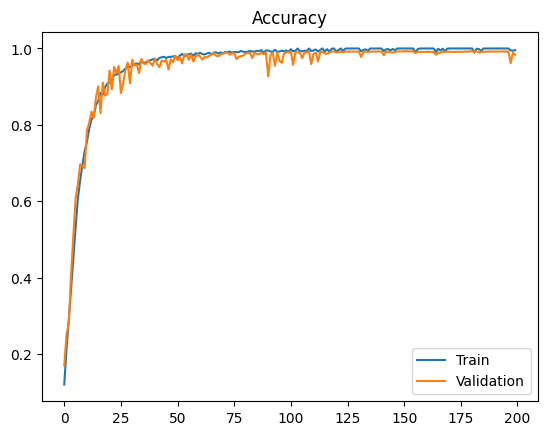

In [ ]:
# Accuracy curve
plt.plot(history_mod3.history['accuracy'])
plt.plot(history_mod3.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

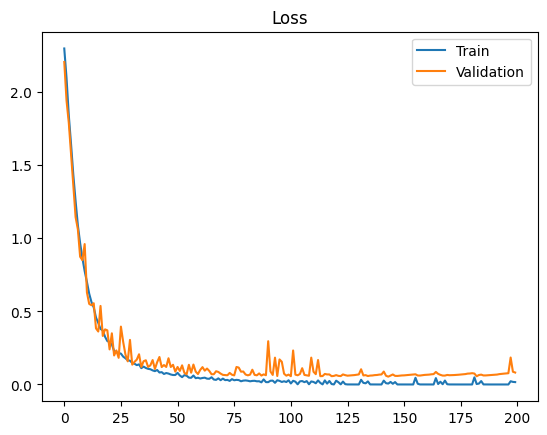

In [ ]:
# Loss curve
plt.plot(history_mod3.history['loss'])
plt.plot(history_mod3.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
val_loss, val_acc = model1c.evaluate(val_ds)
print("Val Accuracy:", val_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9837 - loss: 0.0718
Val Accuracy: 0.9837162494659424


In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1c.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Time per image (seconds): 0.011133655905723572
Time per image (milliseconds): 11.133655905723572


In [ ]:
def original_model_mod4(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 2
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Global pooling layer
  x = layers.GlobalAveragePooling2D()(x)

  outputs = layers.Dense(10,activation="softmax")(x)

  model = models.Model(inputs, outputs, name="Original_CNN_mod4")
  return model

In [ ]:
model1d = original_model_mod4()
model1d.summary()

Model: "Original_CNN_mod4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,722 (209.85 KB)

 Trainable params: 53,722 (209.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1d.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mod4 = model1d.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - accuracy: 0.1090 - loss: 2.5277 - val_accuracy: 0.1173 - val_loss: 2.2968
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 61s 52ms/step - accuracy: 0.1264 - loss: 2.2918 - val_accuracy: 0.1845 - val_loss: 2.2096
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.1974 - loss: 2.1662 - val_accuracy: 0.2806 - val_loss: 1.9628
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.2822 - loss: 1.9128 - val_accuracy: 0.3701 - val_loss: 1.7386
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.3474 - loss: 1.7296 - val_accuracy: 0.3681 - val_loss: 1.6557
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.4079 - loss: 1.5934 - val_accuracy: 0.4812 - val_loss: 1.4843
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.4535 - loss: 1.4826 - val_accuracy: 0.5217 - val_loss: 1.3960
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.5154 - loss: 1

In [ ]:
model1d.save("/content/data/models/original_cnn_mod4.keras")

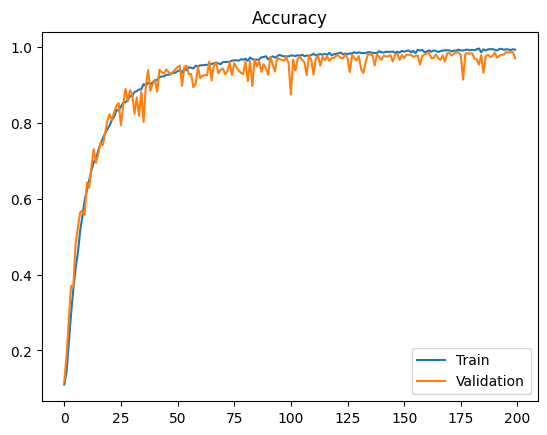

In [ ]:
# Accuracy curve
plt.plot(history_mod4.history['accuracy'])
plt.plot(history_mod4.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

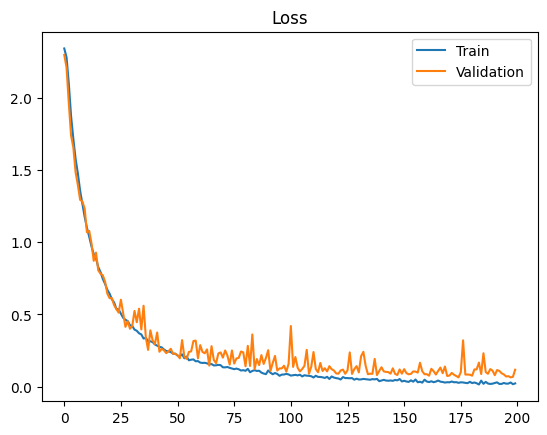

In [ ]:
# Loss curve
plt.plot(history_mod4.history['loss'])
plt.plot(history_mod4.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model1d.evaluate(test_ds)
print("Test Accuracy:", test_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9816 - loss: 0.0753
Test Accuracy: 0.9719376564025879


In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1d.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
Time per image (seconds): 0.04499496519565582
Time per image (milliseconds): 44.99496519565582


In [ ]:
def original_model_mod5(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Global pooling layer
  x = layers.GlobalAveragePooling2D()(x)

  outputs = layers.Dense(10,activation="softmax")(x)

  model = models.Model(inputs, outputs, name="Original_CNN_mod5")
  return model

In [ ]:
model1e = original_model_mod5()
model1e.summary()

Model: "Original_CNN_mod5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,098 (58.98 KB)

 Trainable params: 15,098 (58.98 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1e.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mod5 = model1e.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 52s 51ms/step - accuracy: 0.1091 - loss: 2.5690 - val_accuracy: 0.1528 - val_loss: 2.2891
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.1426 - loss: 2.2817 - val_accuracy: 0.1829 - val_loss: 2.2624
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.1799 - loss: 2.2515 - val_accuracy: 0.1771 - val_loss: 2.2404
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.1905 - loss: 2.2199 - val_accuracy: 0.2075 - val_loss: 2.1831
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.2113 - loss: 2.1522 - val_accuracy: 0.2233 - val_loss: 2.1189
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.2212 - loss: 2.1091 - val_accuracy: 0.2414 - val_loss: 2.0551
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.2476 - loss: 2.0474 - val_accuracy: 0.2739 - val_loss: 2.0192
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.2746 - loss: 1

In [ ]:
model1e.save("/content/data/models/original_cnn_mod5.keras")

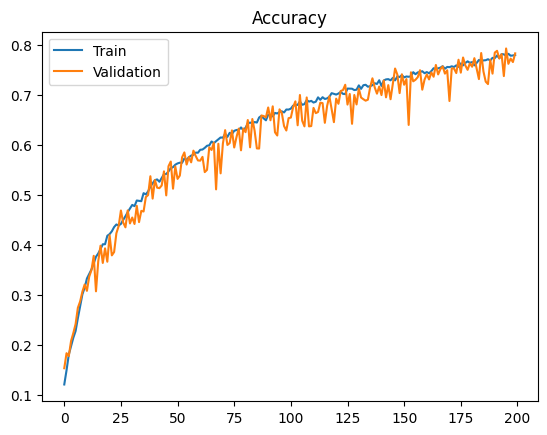

In [ ]:
# Accuracy curve
plt.plot(history_mod5.history['accuracy'])
plt.plot(history_mod5.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

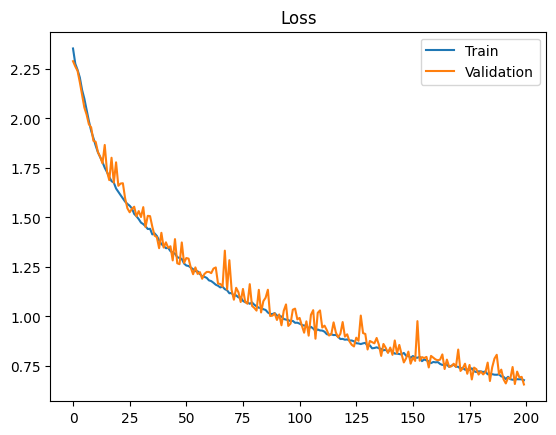

In [ ]:
# Loss curve
plt.plot(history_mod5.history['loss'])
plt.plot(history_mod5.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model1e.evaluate(test_ds)
print("Test Accuracy:", test_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7734 - loss: 0.6847
Test Accuracy: 0.8020044565200806


In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1e.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
Time per image (seconds): 0.0444616973400116
Time per image (milliseconds): 44.4616973400116
